# Face Recognition by DINO Vision Transformer

#### This notebook referred to the greatest sachin's notebook "DINO Self Supervised Vision Transformers".
https://www.kaggle.com/sachin/dino-self-supervised-vision-transformers

# What is DINO?
#### PAPER: "Emerging Properties in Self-Supervised Vision Transformers", released in 2021
https://arxiv.org/pdf/2104.14294.pdf<br/>
- Self-supervised ViT features contain explicit information about the semantic segmentation of an image
- These features are also excellent k-NN classifiers

#### GitHub: Self-Supervised Vision Transformers with DINO
https://github.com/facebookresearch/dino

#### YouTube: DINO: Emerging Properties in Self-Supervised Vision Transformers (Facebook AI Research Explained)
https://www.youtube.com/watch?v=h3ij3F3cPIk<br/>

In [ ]:
# hide
!pip install deepspeed
import copy
from pathlib import Path
from typing import Any, Callable, List, Tuple

from deepspeed.ops.adam import FusedAdam
import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import io, transforms
from torchvision.transforms.functional import to_pil_image
from tqdm.auto import tqdm

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

%matplotlib inline
print(torch.__version__, pl.__version__)

In [ ]:
# Image parameters
TRAIN_FILES = "./data/train"  # path to VGGFace2 train folder on your machine
IMAGE_SIZE = 224  # matches the resolution the pretrained DINO ViT was trained on
LOCAL_SIZE = 96  # resolution of the small "local" crops used in the multi-crop strategy
TOPK = 10

# Multi-crop strategy (DINO paper): a few large "global" crops + several small "local" crops per image
N_GLOBAL_CROPS = 2  # global crops, seen by both teacher and student
N_LOCAL_CROPS = 4  # local crops, seen by the student only
GLOBAL_SCALE = (0.4, 1.0)  # global crops sample most of the face
LOCAL_SCALE = (0.05, 0.4)  # local crops sample small, zoomed-in regions

# Pretrained backbone (fine-tuning instead of training from scratch)
BACKBONE_NAME = "dino_vitb16"  # upgraded from dino_vits16 — ViT-Base has more capacity than ViT-Small
BACKBONE_DIM = 768  # dino_vitb16's native output dimension (was 384 for ViT-S)
EMBED_DIM = 256  # output dim of the projection head, not the raw backbone — DINO trains in this space
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training parameters — fine-tuning needs far fewer epochs and a smaller LR than training from scratch
BATCH_SIZE = 32  # reduced from 64 — ViT-Base + 6 views/sample (multi-crop) needs more VRAM per sample
EPOCHS = 30  # increased from 15 — multi-crop + the cosine schedule benefit from a longer training budget
LR = 3e-5
WARMUP_EPOCHS = 2  # linear LR warmup duration before the cosine schedule takes over

# Update constants
TEMPERATURE_S = 0.1
TEMPERATURE_T = 0.05
CENTER_MOMENTUM = 0.9
TEACHER_MOMENTUM = 0.996  # increased from 0.995 — a slower-moving teacher pairs better with the longer schedule

# Checkpoint
SAVE_EVERY_N_EPOCHS = 3

# Optional supervised second stage (see the cell after the main training loop)
RUN_ARCFACE_STAGE = True  # set to False to skip ArcFace fine-tuning and stop after DINO training
ARCFACE_EPOCHS = 10
ARCFACE_LR = 1e-4

print(f"Training data: {TRAIN_FILES}")
print(f"Backbone: {BACKBONE_NAME} (backbone_dim={BACKBONE_DIM}, projection_dim={EMBED_DIM})")

In [ ]:
CHECKPOINT_DIR        = Path("./checkpoints")
CHECKPOINT_LOCAL_PATH = CHECKPOINT_DIR / "last.ckpt"

checkpoint_callback = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename="dino_epoch={epoch:02d}",
    save_last=True,
    every_n_epochs=SAVE_EVERY_N_EPOCHS,
)

print(f"Checkpoints will be saved to: {CHECKPOINT_DIR.resolve()}")
if CHECKPOINT_LOCAL_PATH.exists():
    print("Existing checkpoint found — training will resume from it.")
else:
    print("No existing checkpoint — training will start fresh.")

In [ ]:
class ImageData(Dataset):
    def __init__(self, files: List[str]):
        self.files = files
        self.global_crop = transforms.RandomResizedCrop((IMAGE_SIZE, IMAGE_SIZE), scale=GLOBAL_SCALE)
        self.local_crop = transforms.RandomResizedCrop((LOCAL_SIZE, LOCAL_SIZE), scale=LOCAL_SCALE)
        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
            transforms.RandomRotation(degrees=30),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # added: simulates pose/viewpoint variation
        ])
        self.normalize = transforms.Compose([
            transforms.ConvertImageDtype(torch.float32),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # added: simulates occlusion (glasses, masks, hands)
        ])

    def __len__(self):
        return len(self.files)

    def _view(self, img: torch.Tensor, crop_fn: Callable) -> torch.Tensor:
        return self.normalize(self.augment(crop_fn(img)))

    def __getitem__(self, i):
        img = io.read_image(self.files[i])
        if img.shape[0] == 1:
            img = torch.cat([img] * 3)

        global_views = [self._view(img, self.global_crop) for _ in range(N_GLOBAL_CROPS)]
        local_views = [self._view(img, self.local_crop) for _ in range(N_LOCAL_CROPS)]

        return tuple(global_views + local_views)


class CollateFn:
    def __call__(
        self, batch: List[Tuple[torch.Tensor, ...]]
    ) -> Tuple[torch.FloatTensor, ...]:
        views = list(zip(*batch))  # transpose: one tensor list per view index
        return tuple(torch.stack(v) for v in views)

In [ ]:
# hide
class ImageOriginalData(Dataset):
    def __init__(self, files: List[str]):
        self.files = files
        self.labels = [Path(f).parent.name for f in files]  # identity = parent folder name (VGGFace2 layout)
        self.resize = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))
        self.normalize = transforms.Compose([
            transforms.ConvertImageDtype(torch.float32),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        img = io.read_image(self.files[i])
        if img.shape[0] == 1:
            img = torch.cat([img]*3)

        return self.normalize(self.resize(img)), self.labels[i]


class CollateSingleImage:
    def __call__(self, batch: List[Tuple[torch.Tensor, str]]) -> Tuple[torch.FloatTensor, List[str]]:
        images, labels = zip(*batch)
        return torch.stack(images), list(labels)


files = [str(file) for file in Path(TRAIN_FILES).rglob("*.jpg")]
train_files, valid_files = train_test_split(files, test_size=0.15, random_state=42)

train_data = ImageData(train_files)
train_dl = DataLoader(
    train_data, 
    BATCH_SIZE, 
    shuffle=True, 
    drop_last=True, 
    num_workers=4,
    pin_memory=True,
    collate_fn=CollateFn(),
)

valid_data = ImageOriginalData(valid_files)
valid_dl = DataLoader(
    valid_data, 
    BATCH_SIZE*2, 
    shuffle=False, 
    drop_last=False, 
    num_workers=4,
    pin_memory=True,
    collate_fn=CollateSingleImage(),
)

In [ ]:
views = next(iter(train_dl))
images, labels = next(iter(valid_dl))
[v.shape for v in views], images.shape, labels[:5]

In [ ]:
class Model(nn.Module):
    def __init__(self, backbone_name: str = BACKBONE_NAME):
        super().__init__()
        self.backbone = torch.hub.load("facebookresearch/dino:main", backbone_name)
        self.projection_head = nn.Sequential(
            nn.Linear(BACKBONE_DIM, 2048),
            nn.GELU(),
            nn.Linear(2048, 2048),
            nn.GELU(),
            nn.Linear(2048, EMBED_DIM),
        )

    def forward(self, x):
        features = self.backbone(x)
        projected = self.projection_head(features)
        return F.normalize(projected, dim=-1)

In [9]:
class HLoss:
    def __init__(self, temperature_t: float, temperature_s: float):
        self.temperature_t = temperature_t
        self.temperature_s = temperature_s
        
    def __call__(
        self, 
        t: torch.FloatTensor, 
        s: torch.FloatTensor, 
        center: torch.FloatTensor
    ) -> torch.FloatTensor:
        t = F.softmax((t.detach() - center) / self.temperature_t, dim=1)
        log_s = F.log_softmax(s / self.temperature_s, dim=1)

        return -(t * log_s).sum(dim=1).mean()

In [ ]:
resize = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))

def get_closest(embedding: torch.FloatTensor, i: int):
    similarity = embedding @ embedding[i, :].T
    scores, idx = similarity.topk(TOPK)
    return scores.cpu().numpy(), idx.cpu().numpy()

In [ ]:
class LightningModel(pl.LightningModule):
    def __init__(
        self,
        teacher: nn.Module,
        lr: float,
        loss_fn: Callable,
        dim: int,
        center_momentum: float,
        param_momentum: float,
    ):
        super().__init__()
        self.teacher = teacher
        self.student = copy.deepcopy(teacher)
        self.lr = lr
        self.loss_fn = loss_fn
        self.c_mom = center_momentum
        self.p_mom = param_momentum
        self.register_buffer("center", torch.zeros((1, dim)).float())

        for p in self.teacher.parameters():
            p.requires_grad = False

    def loss_calculation(
        self,
        batch: Tuple[torch.FloatTensor, ...],
    ) -> torch.FloatTensor:
        views = batch  # N_GLOBAL_CROPS global views followed by N_LOCAL_CROPS local views

        student_outputs = [self.student(v) for v in views]
        teacher_outputs = [self.teacher(v) for v in views[:N_GLOBAL_CROPS]]

        loss = 0.0
        n_terms = 0
        for t_idx, t_out in enumerate(teacher_outputs):
            for s_idx, s_out in enumerate(student_outputs):
                if s_idx == t_idx:
                    continue  # exclude pairing a view with itself
                loss = loss + self.loss_fn(t_out, s_out, self.center)
                n_terms += 1
        loss = loss / n_terms

        emperical_center = F.normalize(
            torch.cat(teacher_outputs).mean(dim=0, keepdims=True),
            dim=-1,
        )
        return loss, emperical_center

    def training_step(
        self, batch: Tuple[torch.FloatTensor, ...], *args: List[Any]
    ) -> torch.Tensor:
        loss, emperical_center = self.loss_calculation(batch)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)

        self.center = F.normalize(
            self.c_mom * self.center + (1 - self.c_mom) * emperical_center,
            dim=-1,
        )
        for s_p, t_p in zip(self.student.parameters(), self.teacher.parameters()):
            t_p.data = self.p_mom * t_p.data + (1 - self.p_mom) * s_p.data

        return loss

    def validation_step(
        self, batch: Tuple[torch.FloatTensor, List[str]], *args: List[Any]
    ) -> None:
        images, labels = batch
        embeddings = self.teacher(images)

        similarity = embeddings @ embeddings.T
        similarity.fill_diagonal_(-1.0)  # exclude a sample from matching itself
        nearest_idx = similarity.argmax(dim=1)

        correct = sum(
            labels[i] == labels[nearest_idx[i].item()] for i in range(len(labels))
        )
        acc = torch.tensor(correct / len(labels), device=self.device)
        self.log("val_rank1_acc", acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = FusedAdam(self.student.parameters(), lr=self.lr)

        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.01, total_iters=WARMUP_EPOCHS
        )
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS, eta_min=1e-6
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[WARMUP_EPOCHS],
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

In [ ]:
teacher = Model(BACKBONE_NAME)
h_loss = HLoss(TEMPERATURE_T, TEMPERATURE_S)
lightning_model = LightningModel(
    teacher,
    LR,
    h_loss,
    EMBED_DIM,
    CENTER_MOMENTUM,
    TEACHER_MOMENTUM,
)

resume_path = str(CHECKPOINT_LOCAL_PATH) if CHECKPOINT_LOCAL_PATH.exists() else None
if resume_path:
    print(f"Resuming from: {resume_path}")
else:
    print("Starting fresh.")

trainer = pl.Trainer(
    max_epochs=EPOCHS,
    gpus=torch.cuda.device_count(),
    gradient_clip_val=1.0,
    precision=16,
    num_sanity_val_steps=0,
    callbacks=[checkpoint_callback],
    resume_from_checkpoint=resume_path,
)
trainer.fit(lightning_model, train_dl, valid_dl)
print("Training complete.")

In [ ]:
if RUN_ARCFACE_STAGE:
    !pip install pytorch-metric-learning --quiet
    from pytorch_metric_learning.losses import ArcFaceLoss

    class IdentityLabeledData(Dataset):
        def __init__(self, files: List[str], label_to_idx: dict):
            self.files = files
            self.labels = [label_to_idx[Path(f).parent.name] for f in files]
            self.crop = transforms.RandomResizedCrop((IMAGE_SIZE, IMAGE_SIZE), scale=(0.5, 1.0))
            self.normalize = transforms.Compose([
                transforms.ConvertImageDtype(torch.float32),
                transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ])

        def __len__(self):
            return len(self.files)

        def __getitem__(self, i):
            img = io.read_image(self.files[i])
            if img.shape[0] == 1:
                img = torch.cat([img] * 3)
            return self.normalize(self.crop(img)), self.labels[i]

    # each subfolder under TRAIN_FILES is one identity (VGGFace2 layout)
    identity_names = sorted(d.name for d in Path(TRAIN_FILES).iterdir() if d.is_dir())
    NUM_IDENTITIES = len(identity_names)
    label_to_idx = {name: idx for idx, name in enumerate(identity_names)}
    print(f"ArcFace stage: {NUM_IDENTITIES} identities found under {TRAIN_FILES}")

    arcface_data = IdentityLabeledData(train_files, label_to_idx)
    arcface_dl = DataLoader(
        arcface_data,
        BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        num_workers=4,
        pin_memory=True,
    )

    arcface_model = lightning_model.student  # continue from the DINO-fine-tuned student
    for p in arcface_model.backbone.parameters():
        p.requires_grad = False  # freeze the backbone — only the projection head adapts now
    arcface_model = arcface_model.to(device)

    arcface_loss_fn = ArcFaceLoss(
        num_classes=NUM_IDENTITIES, embedding_size=EMBED_DIM
    ).to(device)

    arcface_optimizer = torch.optim.Adam(
        list(arcface_model.projection_head.parameters()) + list(arcface_loss_fn.parameters()),
        lr=ARCFACE_LR,
    )

    arcface_model.train()
    for epoch in range(ARCFACE_EPOCHS):
        running_loss = 0.0
        for images, labels in tqdm(arcface_dl, desc=f"ArcFace epoch {epoch + 1}/{ARCFACE_EPOCHS}"):
            images, labels = images.to(device), labels.to(device)

            embeddings = arcface_model(images)
            loss = arcface_loss_fn(embeddings, labels)

            arcface_optimizer.zero_grad()
            loss.backward()
            arcface_optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch + 1}: ArcFace loss = {running_loss / len(arcface_dl):.4f}")

    arcface_checkpoint_path = CHECKPOINT_DIR / "arcface_finetuned.pt"
    torch.save(arcface_model.state_dict(), arcface_checkpoint_path)
    print(f"ArcFace fine-tuned model saved to {arcface_checkpoint_path}")
else:
    print("Skipping ArcFace stage (RUN_ARCFACE_STAGE = False).")

In [13]:
# hide
image_orig_data = ImageOriginalData(files)
image_orig_dl = DataLoader(
    image_orig_data, 
    BATCH_SIZE*2, 
    shuffle=False, 
    drop_last=False, 
    num_workers=4,
    pin_memory=True,
    collate_fn=CollateSingleImage(),
)

In [ ]:
teacher = teacher.eval().to(device)
embedding = []
with torch.no_grad():
    for x, _ in tqdm(image_orig_dl):
        out = teacher(x.to(device))
        embedding.append(out.cpu())
        
    embedding = torch.cat(embedding, dim=0)

In [16]:
def plot_closest_pairs(embedding, i, files):
    img = to_pil_image(resize(io.read_image(files[i])))
    plt.imshow(img)
    scores, idx = get_closest(embedding, i)
    print(idx)
    print(scores)
    fig, axs = plt.subplots(2,5, figsize=(12,5))
    for j in range(10):
        i=idx[j]
        score=scores[j]
        r=j//5
        c=j%5
        img = to_pil_image(resize(io.read_image(files[i])))
        axs[r][c].imshow(img)
        axs[r][c].axis("off")
        axs[r][c].set_title(f"{score:.4f}")

    plt.show()

[ 64 108  79 110 103  18   3  21  89  62]
[1.0000001  0.8790609  0.86133575 0.8386327  0.8359523  0.82507294
 0.82287484 0.7943871  0.7797829  0.76200354]


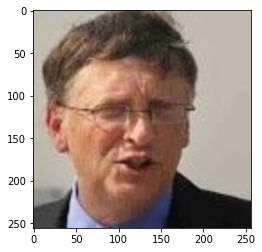

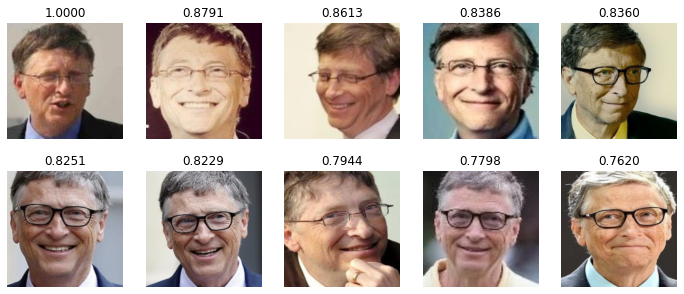

In [17]:
i = 64
plot_closest_pairs(embedding, i, files)

[ 42  69   2  70  33  98  87 119  84  37]
[1.         0.9924176  0.93069834 0.92685115 0.9267898  0.90857834
 0.9044742  0.9001832  0.88606906 0.88565   ]


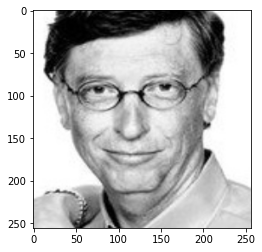

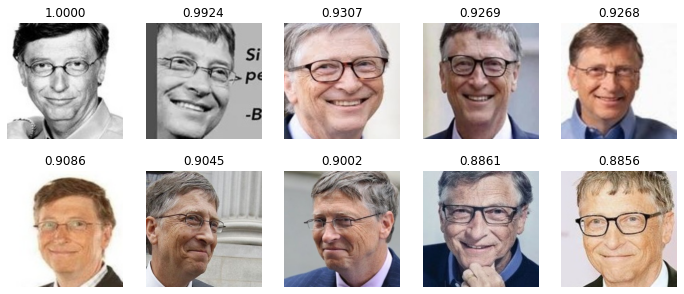

In [18]:
i = 42
plot_closest_pairs(embedding, i, files)

[ 21  34  62  73   9 108  77  47  48  14]
[1.0000001  0.97578496 0.96955764 0.9419818  0.93891156 0.93039316
 0.9260252  0.9219821  0.91227955 0.90565056]


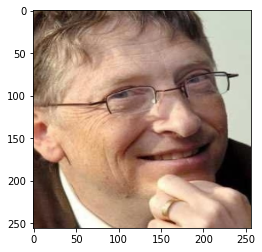

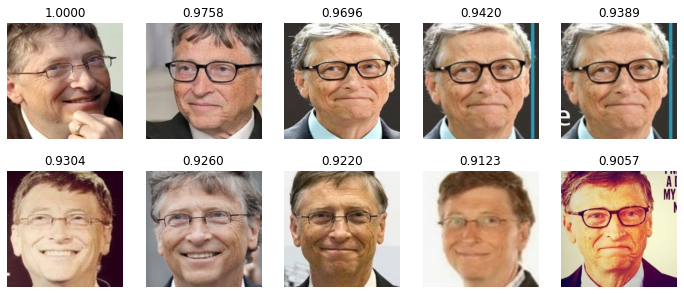

In [19]:
i = 21
plot_closest_pairs(embedding, i, files)